In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
import geopandas as gpd
import xarray as xr

In [2]:
%pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 45.7 MB/s eta 0:00:00


In [3]:
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

In [4]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


Aqui va la CARPETA DONDE SUS DATOS DE ANOMALIA DE ALTURA DE NIVEL DE MAR

In [5]:
path = "/content/drive/MyDrive/3_Horario_2025/CPTA/Monitoreo_ENSO/Monitoreo7/SLA"

# Abriendo archivos

In [6]:
sla_daily_manual = xr.open_dataset(f"{path}/cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_1758732755192.nc")
sla_daily_manual

<xarray.Dataset> Size: 258MB
Dimensions:    (time: 267, latitude: 288, longitude: 840)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2025-01-01 2025-01-02 ... 2025-09-24
  * latitude   (latitude) float32 1kB -17.94 -17.81 -17.69 ... 17.69 17.81 17.94
  * longitude  (longitude) float32 3kB -174.9 -174.8 -174.7 ... -70.19 -70.06
Data variables:
    sla        (time, latitude, longitude) float32 258MB ...
Attributes:
    Conventions:       CF-1.11
    title:             NRT merged all satellites Global Ocean Gridded SSALTO/...
    institution:       CLS, CNES
    source:            Altimetry measurements
    history:           2025-04-17 20:03:53Z: Creation
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    comment:           Sea Surface Height measured by Altimetry and derived v...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SEALEVEL_GLO_PHY_L4_NRT_008_046
    subset:datasetId:  cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_...
    subset:date:       2025-09-24T16:52:35.192Z

In [7]:
sla_monthly = sla_daily_manual.resample(time='MS').mean()
sla_monthly

<xarray.Dataset> Size: 9MB
Dimensions:    (time: 9, latitude: 288, longitude: 840)
Coordinates:
  * latitude   (latitude) float32 1kB -17.94 -17.81 -17.69 ... 17.69 17.81 17.94
  * longitude  (longitude) float32 3kB -174.9 -174.8 -174.7 ... -70.19 -70.06
  * time       (time) datetime64[ns] 72B 2025-01-01 2025-02-01 ... 2025-09-01
Data variables:
    sla        (time, latitude, longitude) float32 9MB 0.1033 0.1091 ... 0.1278
Attributes:
    Conventions:       CF-1.11
    title:             NRT merged all satellites Global Ocean Gridded SSALTO/...
    institution:       CLS, CNES
    source:            Altimetry measurements
    history:           2025-04-17 20:03:53Z: Creation
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    comment:           Sea Surface Height measured by Altimetry and derived v...
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  SEALEVEL_GLO_PHY_L4_NRT_008_046
    subset:datasetId:  cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_...
    subset:date:       2025-09-24T16:52:35.192Z

# Haciendo gif desde ultima fecha

Pongan la carpeta donde quieren que se guarde las imagenes

In [8]:
path_sla = "/content/drive/MyDrive/3_Horario_2025/CPTA/Monitoreo_ENSO/Monitoreo1/SLA/SLA_pic"

In [9]:
def plot_sla_daily(
    sla_data: xr.DataArray,
    date_str: str,
    min_sla_val: float = -10, # en cm
    max_sla_val: float = 15,  # en cm
    sla_levels: int = 21,
    save_fig: bool = False
):
    target_date = pd.to_datetime(date_str)
    sla_to_plot = (sla_data.sel(time=target_date, method='nearest').squeeze() * 100.0) # SLA en cm

    fig, ax = plt.subplots(1, 1, figsize=(12, 8),
                           subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}) # Centrado en el Pacífico
    extent = [-175, -75, -12, 12]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
    ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='black')
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN)

    # Añadiendo grillas.
    gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                      color='gray', linestyle='--', alpha=0.6,
                      xlocs=np.arange(-180, 180, 10), # Longitudes de 0 a 360 cada 30 grados
                      ylocs=np.arange(-90, 91, 10)) # Latitudes de -90 a 90 cada 10 grados
    gl.top_labels = gl.right_labels = False
    # 3. Graficar SLA como mapa de contorno relleno (capa base)
    # Se usa TwoSlopeNorm para centrar el color blanco en 0 (anomalías cero)
    sla_cmap = plt.get_cmap('RdYlBu_r') # Colormap rojo-amarillo-azul invertido
    sla_norm = mcolors.TwoSlopeNorm(vmin=min_sla_val, vcenter=0., vmax=max_sla_val)
    sla_contour_levels = np.linspace(min_sla_val, max_sla_val, sla_levels)

    plot_obj_sla = sla_to_plot.plot.contourf(ax=ax, transform=ccrs.PlateCarree(), cmap=sla_cmap, norm=sla_norm,
                                             levels=sla_contour_levels, add_colorbar=False, extend='both')

    # 6. Título del gráfico
    ax.set_title(f'Anomalía de la Altura del Mar (SLA)\n {target_date.strftime("%Y-%m-%d")}',
                 fontsize=14, fontweight="bold")

    # Ajustar el espacio para la barra de color
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.98]) # Deja espacio a la derecha para la barra de color

    # 7. Barra de color para SLA (asociada al plot_obj_sla)
    cbar_ax = fig.add_axes([0.92, 0.35, 0.02, 0.3]) # Posición de la barra de color [left, bottom, width, height]
    cbar = fig.colorbar(plot_obj_sla, cax=cbar_ax, orientation='vertical')
    cbar.set_label(f'Anomalía de SLA (cm)', fontsize=12, fontweight='bold')

    # 8. Guardar o mostrar la figura
    if save_fig:
        filename = f"SLA_day_{date_str}.png"
        plt.savefig(f"{path_sla}/SLA_Wind_{date_str}.png", dpi=300, bbox_inches='tight')
        print(f"Figura guardada como: SLA_Wind_{date_str}.png")
    else:
        plt.show()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Do

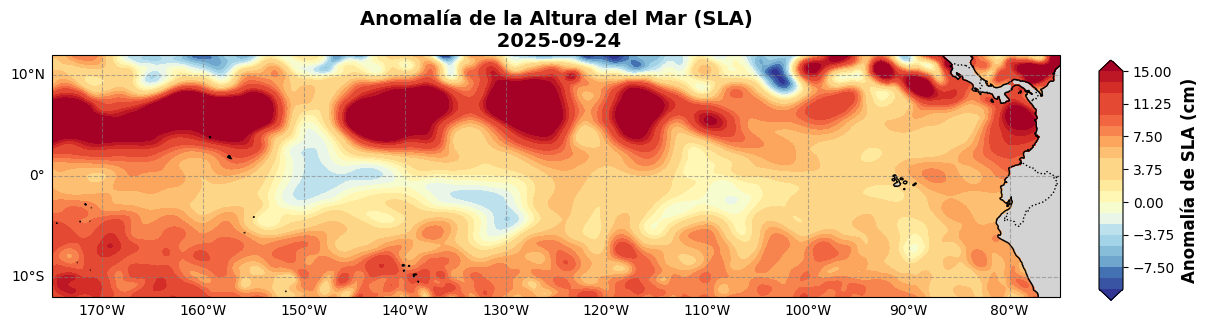

In [10]:
plot_sla_daily(
    sla_daily_manual["sla"], "2025-09-24",
    save_fig= False)

In [11]:
date_range = pd.date_range(start="2025-09-11", end="2025-09-24", freq='D')
date_range

DatetimeIndex(['2025-09-11', '2025-09-12', '2025-09-13', '2025-09-14',
               '2025-09-15', '2025-09-16', '2025-09-17', '2025-09-18',
               '2025-09-19', '2025-09-20', '2025-09-21', '2025-09-22',
               '2025-09-23', '2025-09-24'],
              dtype='datetime64[ns]', freq='D')

Procesando fecha: 2025-09-11
Figura guardada como: SLA_Wind_2025-09-11.png
Procesando fecha: 2025-09-12
Figura guardada como: SLA_Wind_2025-09-12.png
Procesando fecha: 2025-09-13
Figura guardada como: SLA_Wind_2025-09-13.png
Procesando fecha: 2025-09-14
Figura guardada como: SLA_Wind_2025-09-14.png
Procesando fecha: 2025-09-15
Figura guardada como: SLA_Wind_2025-09-15.png
Procesando fecha: 2025-09-16
Figura guardada como: SLA_Wind_2025-09-16.png
Procesando fecha: 2025-09-17
Figura guardada como: SLA_Wind_2025-09-17.png
Procesando fecha: 2025-09-18
Figura guardada como: SLA_Wind_2025-09-18.png
Procesando fecha: 2025-09-19
Figura guardada como: SLA_Wind_2025-09-19.png
Procesando fecha: 2025-09-20
Figura guardada como: SLA_Wind_2025-09-20.png
Procesando fecha: 2025-09-21
Figura guardada como: SLA_Wind_2025-09-21.png
Procesando fecha: 2025-09-22
Figura guardada como: SLA_Wind_2025-09-22.png
Procesando fecha: 2025-09-23
Figura guardada como: SLA_Wind_2025-09-23.png
Procesando fecha: 2025-09

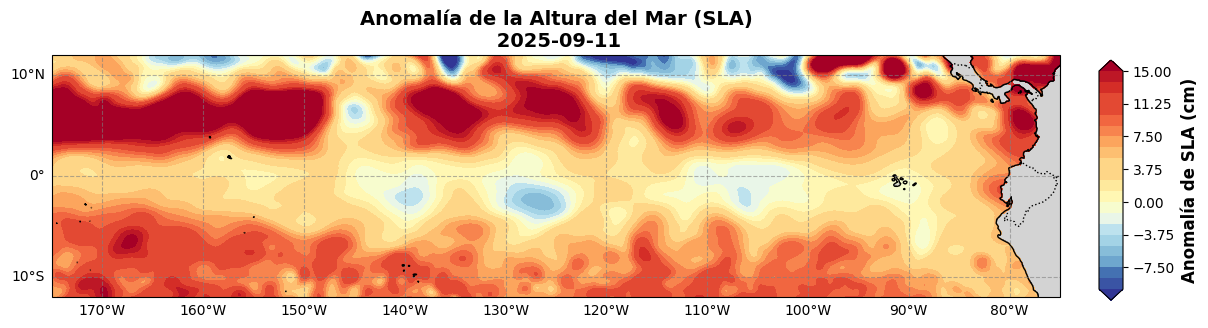

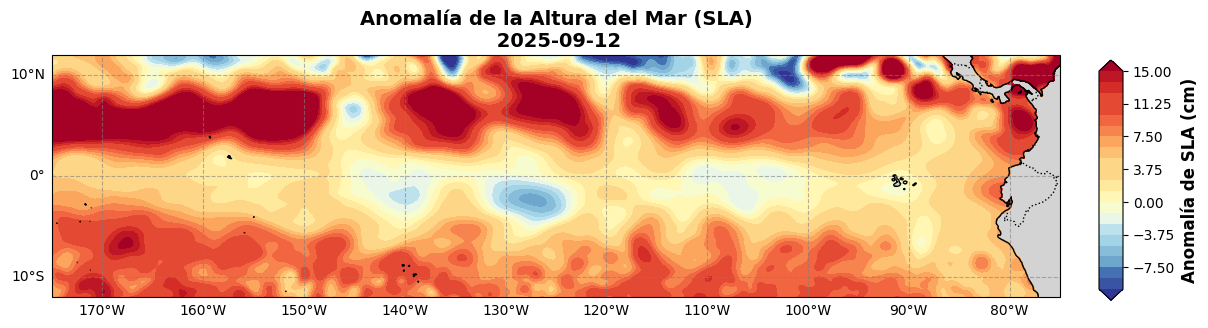

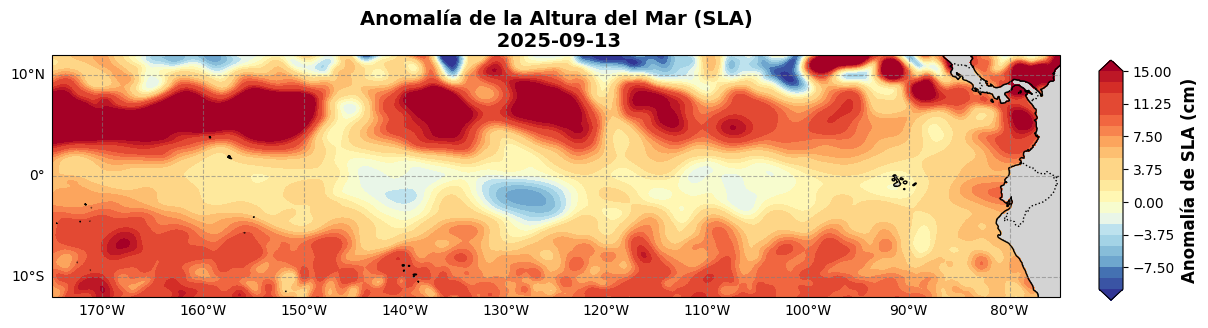

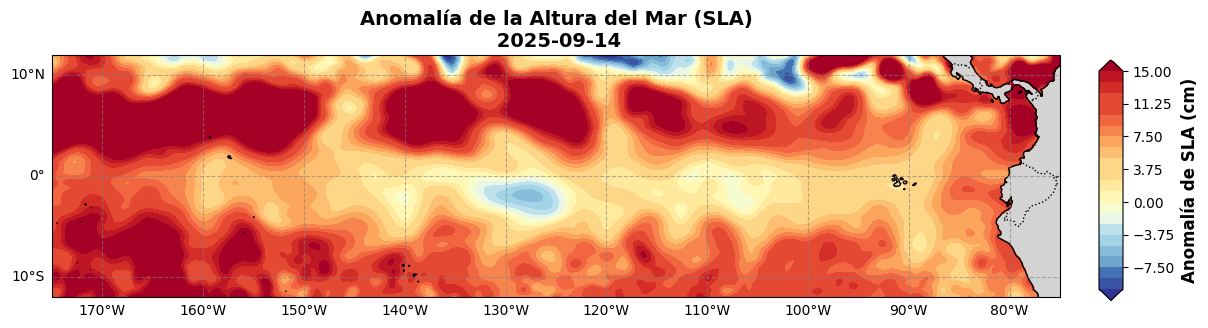

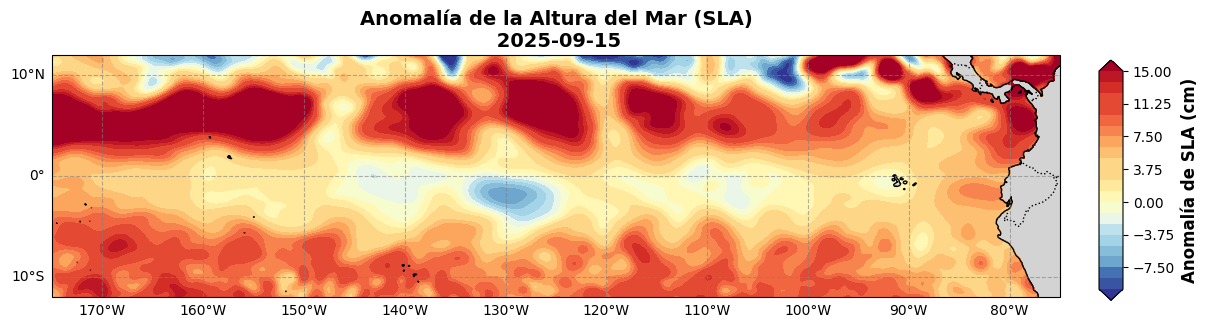

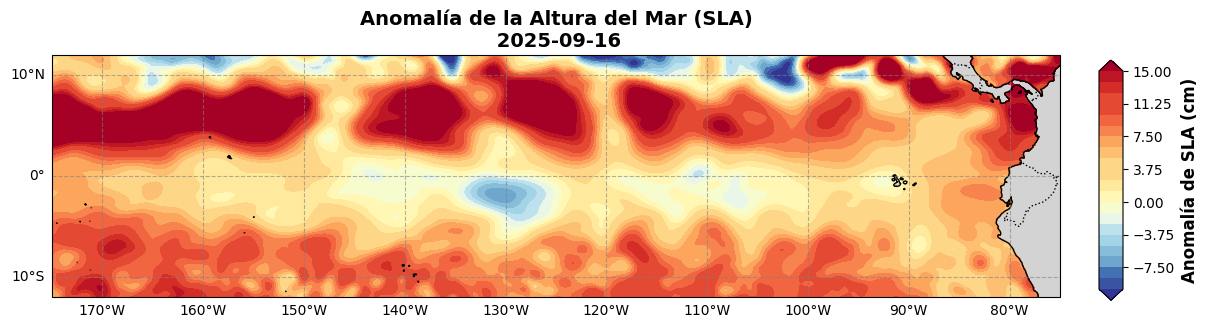

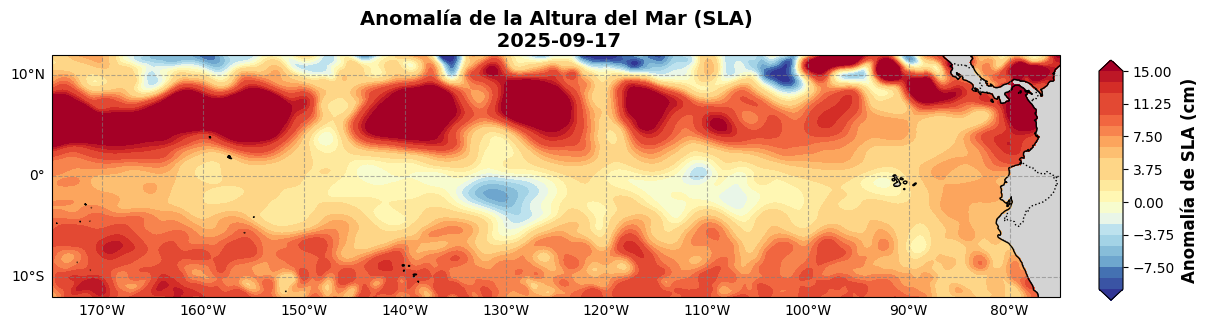

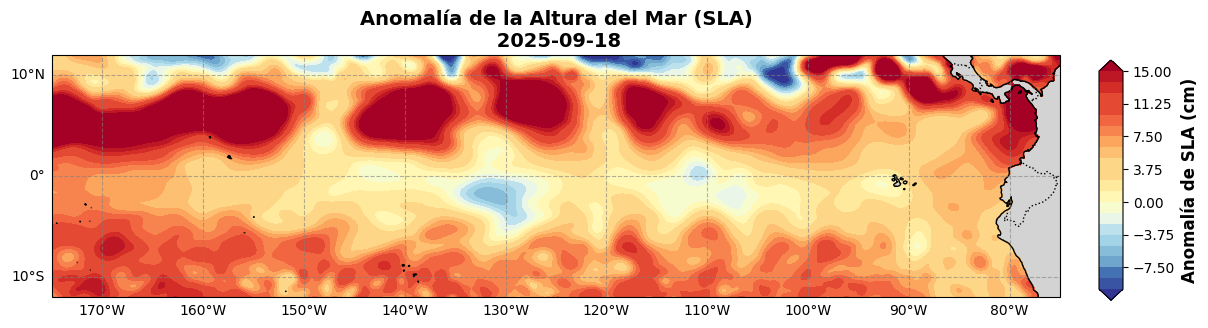

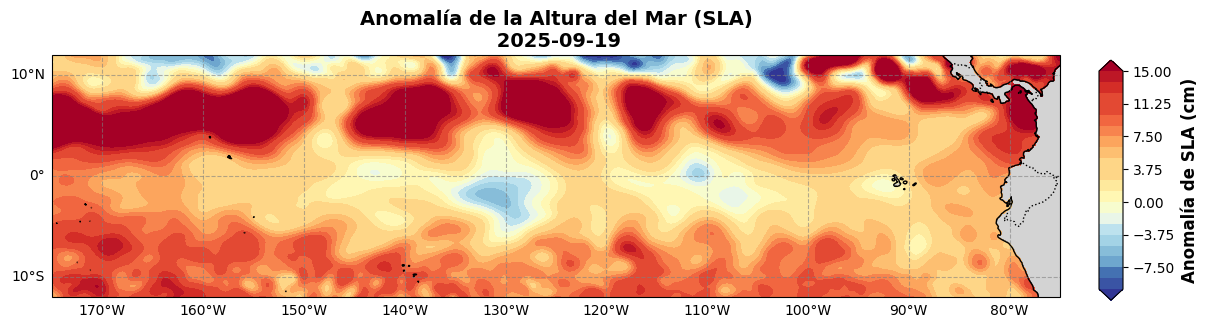

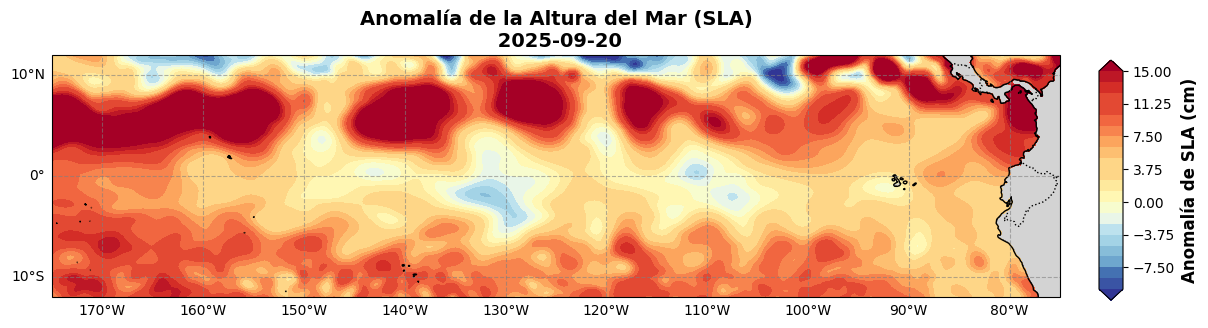

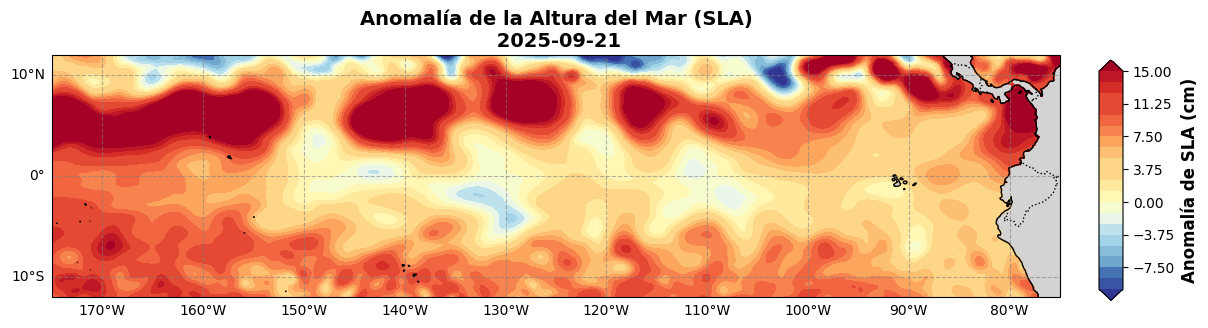

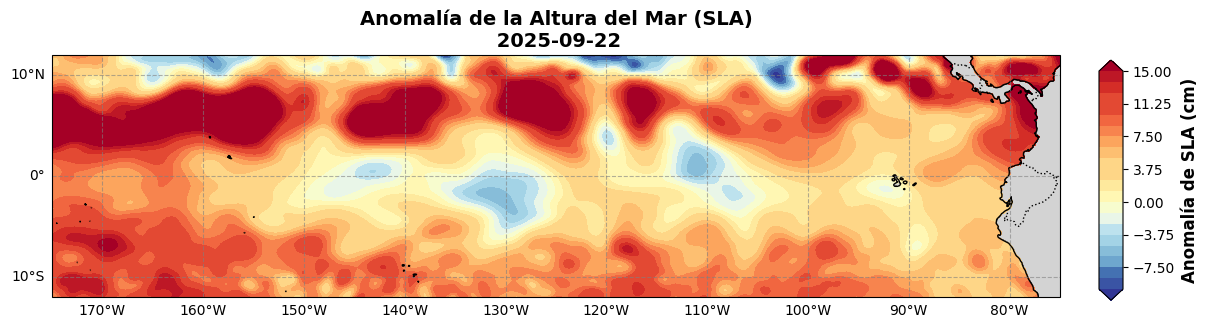

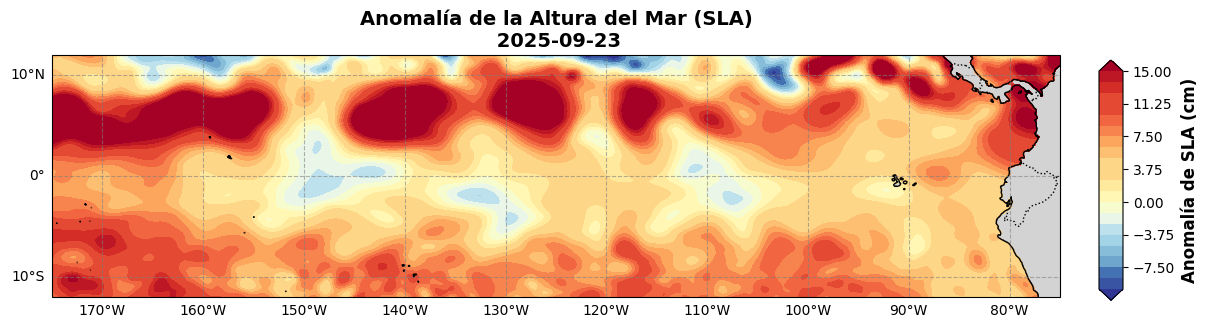

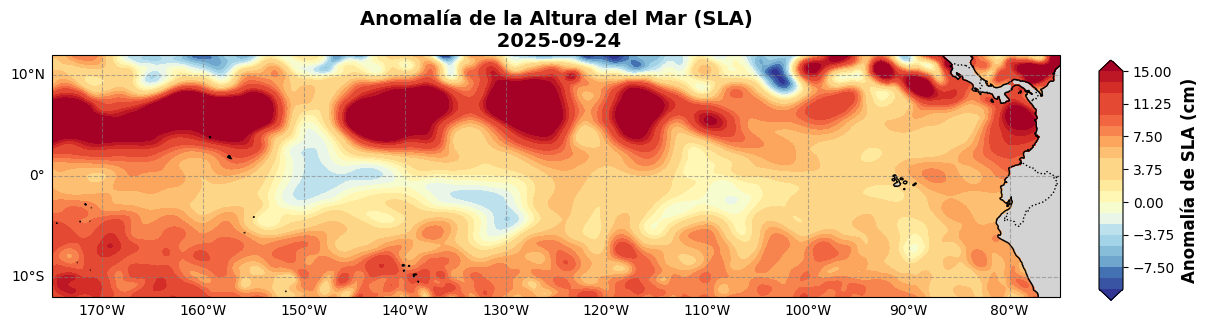

In [12]:
for current_date in date_range:
    date_str_formatted = current_date.strftime('%Y-%m-%d') # Formatear la fecha para la función
    print(f"Procesando fecha: {date_str_formatted}")
    plot_sla_daily(sla_daily_manual["sla"], date_str_formatted, save_fig= True)

In [13]:
import os
import imageio

In [14]:
archivos_sla = sorted(os.listdir(path_sla))  # Ordenar archivos alfabéticamente
archivos_sla

['SLA_Wind_2025-06-01.png',
 'SLA_Wind_2025-06-02.png',
 'SLA_Wind_2025-06-03.png',
 'SLA_Wind_2025-06-04.png',
 'SLA_Wind_2025-06-05.png',
 'SLA_Wind_2025-06-06.png',
 'SLA_Wind_2025-06-07.png',
 'SLA_Wind_2025-06-08.png',
 'SLA_Wind_2025-06-09.png',
 'SLA_Wind_2025-06-10.png',
 'SLA_Wind_2025-06-11.png',
 'SLA_Wind_2025-06-12.png',
 'SLA_Wind_2025-06-13.png',
 'SLA_Wind_2025-06-14.png',
 'SLA_Wind_2025-06-15.png',
 'SLA_Wind_2025-06-16.png',
 'SLA_Wind_2025-06-17.png',
 'SLA_Wind_2025-06-18.png',
 'SLA_Wind_2025-06-19.png',
 'SLA_Wind_2025-06-20.png',
 'SLA_Wind_2025-06-21.png',
 'SLA_Wind_2025-06-22.png',
 'SLA_Wind_2025-06-23.png',
 'SLA_Wind_2025-06-24.png',
 'SLA_Wind_2025-06-25.png',
 'SLA_Wind_2025-06-26.png',
 'SLA_Wind_2025-06-27.png',
 'SLA_Wind_2025-06-28.png',
 'SLA_Wind_2025-06-29.png',
 'SLA_Wind_2025-06-30.png',
 'SLA_Wind_2025-07-01.png',
 'SLA_Wind_2025-07-02.png',
 'SLA_Wind_2025-07-03.png',
 'SLA_Wind_2025-07-04.png',
 'SLA_Wind_2025-07-05.png',
 'SLA_Wind_2025-07-0

In [15]:
# Solo incluir imágenes .png
archivos_sla = [f for f in archivos_sla if f.endswith('.png')]
img_array_sla = []

# Leer imágenes una por una
for nombre in archivos_sla:
    ruta_completa = os.path.join(path_sla, nombre)
    leer_imagen = imageio.imread(ruta_completa)
    img_array_sla.append(leer_imagen)

# Guardar el GIF en el mismo directorio (o puedes elegir otro)
salida = os.path.join(path_sla, 'sla_daily_monitoreo7.gif')
imageio.mimsave(salida, img_array_sla, format='GIF', duration=350)

/tmp/ipython-input-528240428.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  leer_imagen = imageio.imread(ruta_completa)


# Funcion mensual

In [16]:
path_guardar = "/content/drive/MyDrive/3_Horario_2025/CPTA/Monitoreo_ENSO/Monitoreo7/SLA"

In [17]:
def plot_sla_monthly(sla_monthly_data, start_month_str, num_months_to_plot=6, min_val=-5, max_val=5, levels=21, save_fig=False):
    """
    Grafica la Anomalía de la Altura del Mar (SLA) para un número específico de meses
    a partir de una fecha de inicio dada, con zonas de Niño 3.4 y Niño 1+2 resaltadas.

    Args:
        sla_monthly_data (xr.DataArray): DataArray mensual de SLA con dimensiones 'time', 'latitude', 'longitude'.
                                        La variable debe llamarse 'sla'.
        start_month_str (str): Fecha de inicio del primer mes a graficar en formato 'YYYY-MM-DD' (el día no importa, solo el mes y año).
        num_months_to_plot (int): Número de meses consecutivos a graficar (por defecto 6).
        min_val (float): Valor mínimo para la escala de colores (por defecto -5 cm).
        max_val (float): Valor máximo para la escala de colores (por defecto 5 cm).
        levels (int): Número de niveles para el contorno de color (por defecto 21).
    """

    # Convertir a centímetros si no lo está (tu código ya lo hace multiplicando por 100)
    # Si tus datos mensuales ya están en cm, puedes omitir esta línea o ajustarla.
    sla_data_cm = sla_monthly_data * 100.0

    # Convertir la fecha de inicio a datetime y asegurar que es el primer día del mes
    start_date = pd.to_datetime(start_month_str).to_period('M').start_time

    # Calcular las fechas de los meses a graficar
    dates_to_plot = [start_date + pd.DateOffset(months=i) for i in range(num_months_to_plot)]

    # Definir la extensión del mapa
    extent = [-175, -75, -12, 12]

    # Configurar los subplots dinámicamente según el número de meses
    fig, axs = plt.subplots(num_months_to_plot, 1, figsize=(15, 4 * num_months_to_plot),
                            subplot_kw={'projection': ccrs.PlateCarree()})

    # Asegurarse de que axs sea un array de una dimensión para el bucle
    if num_months_to_plot == 1:
        axs = [axs] # Si solo es un subplot, lo convertimos en una lista para iterar

    cmap = plt.get_cmap('RdYlBu_r')
    contour_levels = np.linspace(min_val, max_val, levels)
    norm = mcolors.TwoSlopeNorm(vmin=min_val, vcenter=0., vmax=max_val)

    for i, dt in enumerate(dates_to_plot):
        ax = axs[i]
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.coastlines(resolution='50m')  # Mejor resolución para costas
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
        ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='black')
        ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray') # Para mejor visualización de la tierra
        ax.add_feature(cfeature.OCEAN) # Para mejor visualización del océano

        # Añadiendo grillas.
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                            color='gray', linestyle='--', alpha=0.6,
                            xlocs=np.arange(-180, 181, 10), ylocs=np.arange(-90, 91, 5))
        gl.top_labels = gl.right_labels = False

        # Extraer los datos para el mes actual
        # Usa .sel(time=dt, method='nearest') para manejar posibles pequeñas diferencias en el datetime
        # Asegúrate de que tu `sla_monthly_data` tenga el tiempo como el inicio del mes para que `nearest` funcione bien
        var_ax = sla_data_cm.sel(time=dt, method='nearest')

        # Graficando
        plot_obj = var_ax.plot.contourf(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm,
                                         levels=contour_levels, add_colorbar=False, extend='both')

        ax.set_title(f'Anomalía de la Altura del Mar (SLA) - {dt.strftime("%Y-%m")}', # Formato YYYY-MM para meses
                     fontsize=12, fontweight="bold")

        # Añadir zona Niño 3.4 (5N-5S, 170W-120W)
        ax.add_patch(mpatches.Rectangle(xy=(-170, -5), width=50, height=10,
                                         facecolor='none', edgecolor='black', linewidth=2.5,
                                         transform=ccrs.PlateCarree(), label='Niño 3.4 (170W-120W, 5N-5S)'))
        ax.text(-169, -4, 'Niño 3.4', color='black', fontsize=9, transform=ccrs.PlateCarree())

        # Añadir zona Niño 1+2 (10S-0, 90W-80W)
        ax.add_patch(mpatches.Rectangle(xy=(-90, -10), width=10, height=10,
                                         facecolor='none', edgecolor='black', linewidth=2.5,
                                         transform=ccrs.PlateCarree(), label='Niño 1+2 (90W-80W, 10S-0)'))
        ax.text(-89, -9, 'Niño 1+2', color='black', fontsize=9, transform=ccrs.PlateCarree())

    # Ajustar el espacio entre subplots
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.98])

    # Barra de color
    cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
    cbar = fig.colorbar(plot_obj, cax=cbar_ax, orientation='vertical')
    cbar.set_label(f'Anomalía de SLA (cm)', fontsize=12, fontweight='bold')
    if save_fig:
        plt.savefig(f"{path_guardar}/Monthly_{start_month_str}_{num_months_to_plot}meses.png",
                    dpi=300, bbox_inches='tight') # dpi=300 para buena calidad
        print(f"Figura guardada como: {start_month_str}_{num_months_to_plot}meses.png.png")
    else:
      plt.show()

Figura guardada como: 2025-01-01_3meses.png.png


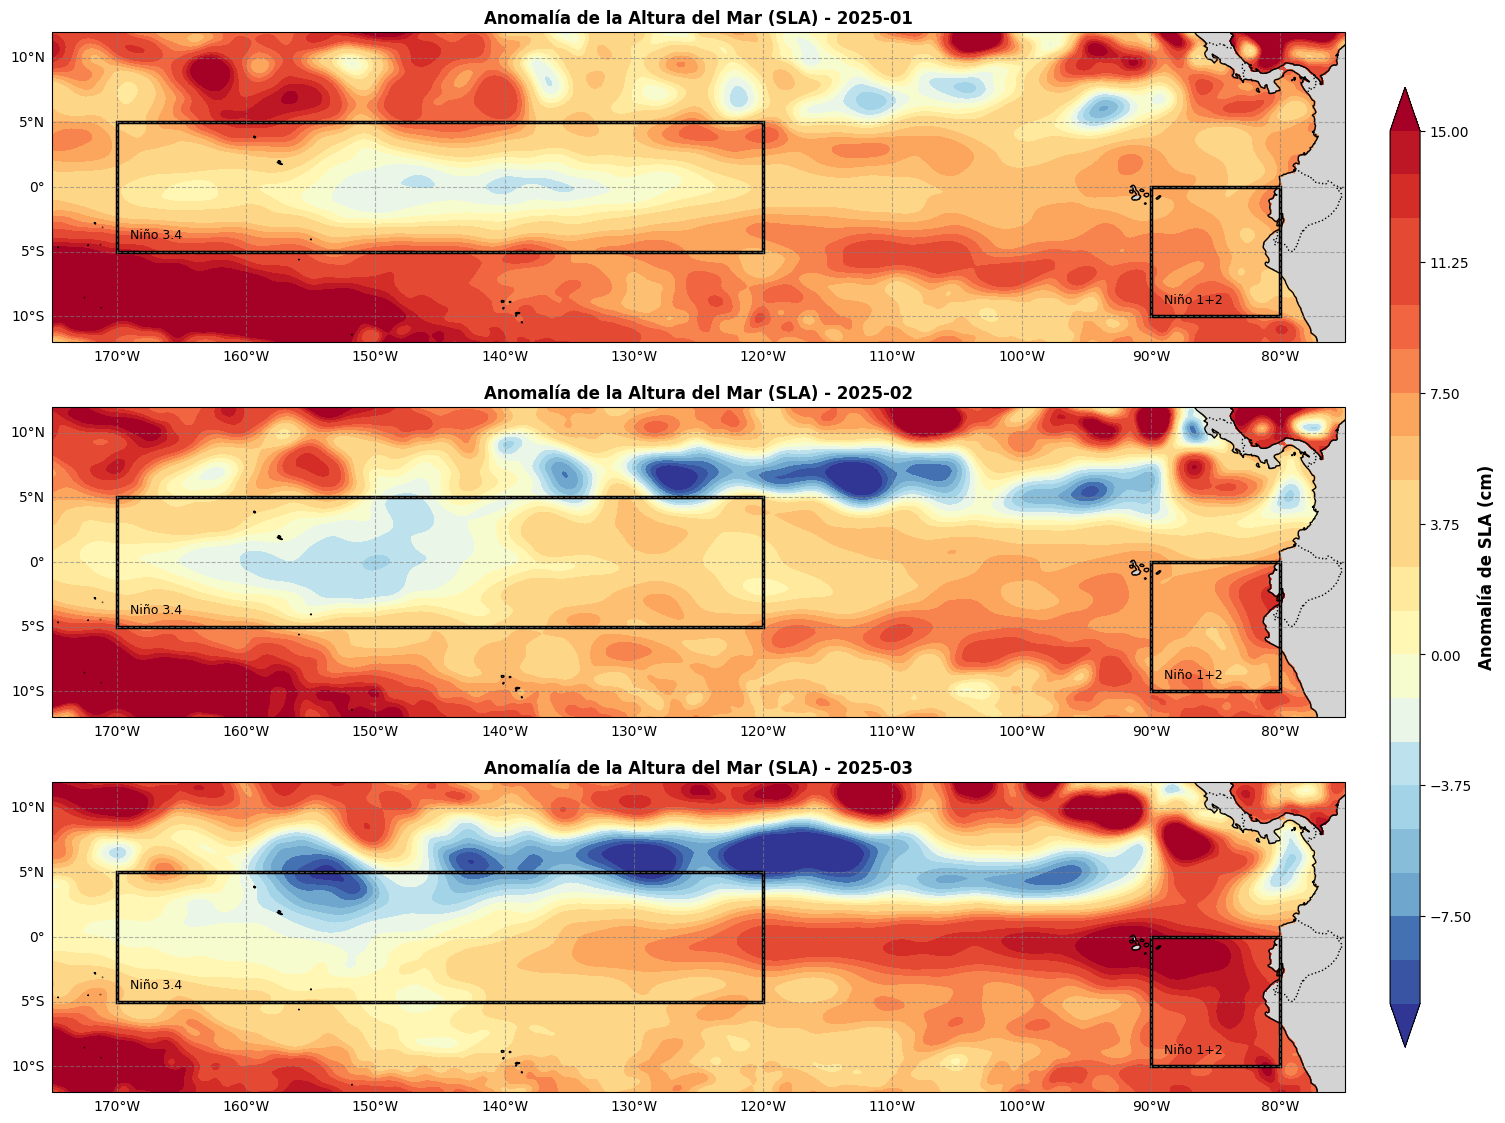

In [20]:
plot_sla_monthly(sla_monthly["sla"], '2025-01-01', num_months_to_plot=3,
                 min_val=-10, max_val=15, levels=21, save_fig=True)

Figura guardada como: 2025-04-01_3meses.png.png


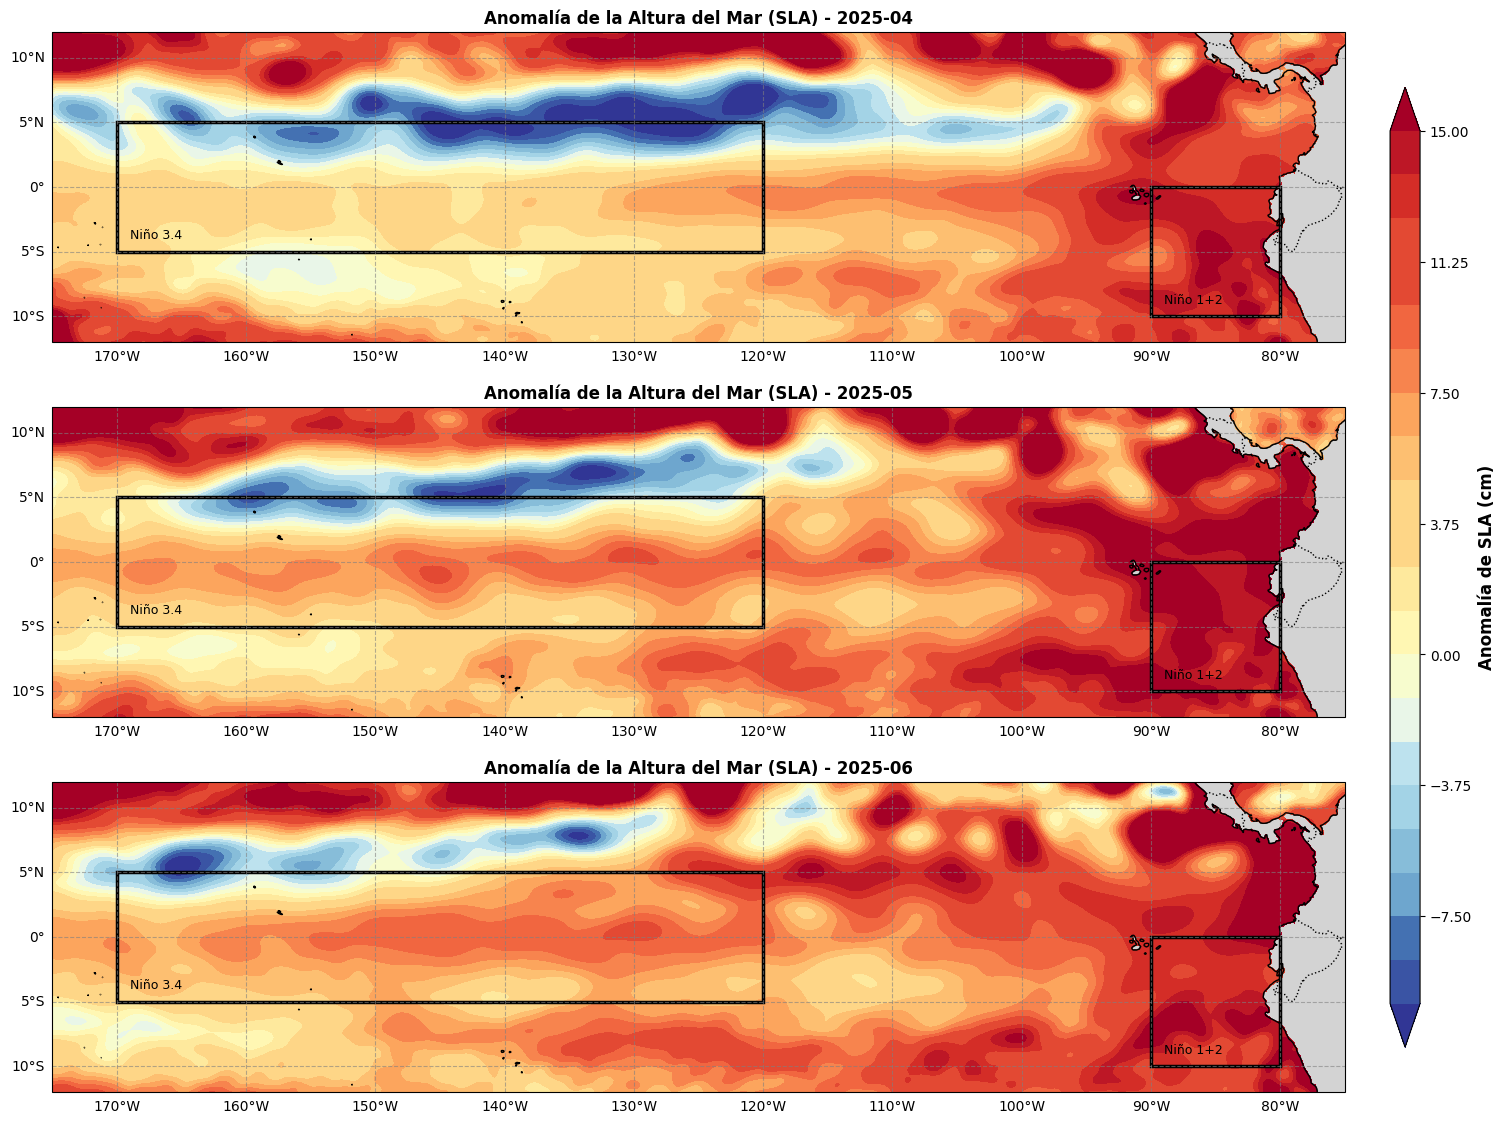

In [18]:
plot_sla_monthly(sla_monthly["sla"], '2025-04-01', num_months_to_plot=3,
                 min_val=-10, max_val=15, levels=21, save_fig=True)

Figura guardada como: 2025-07-01_3meses.png.png


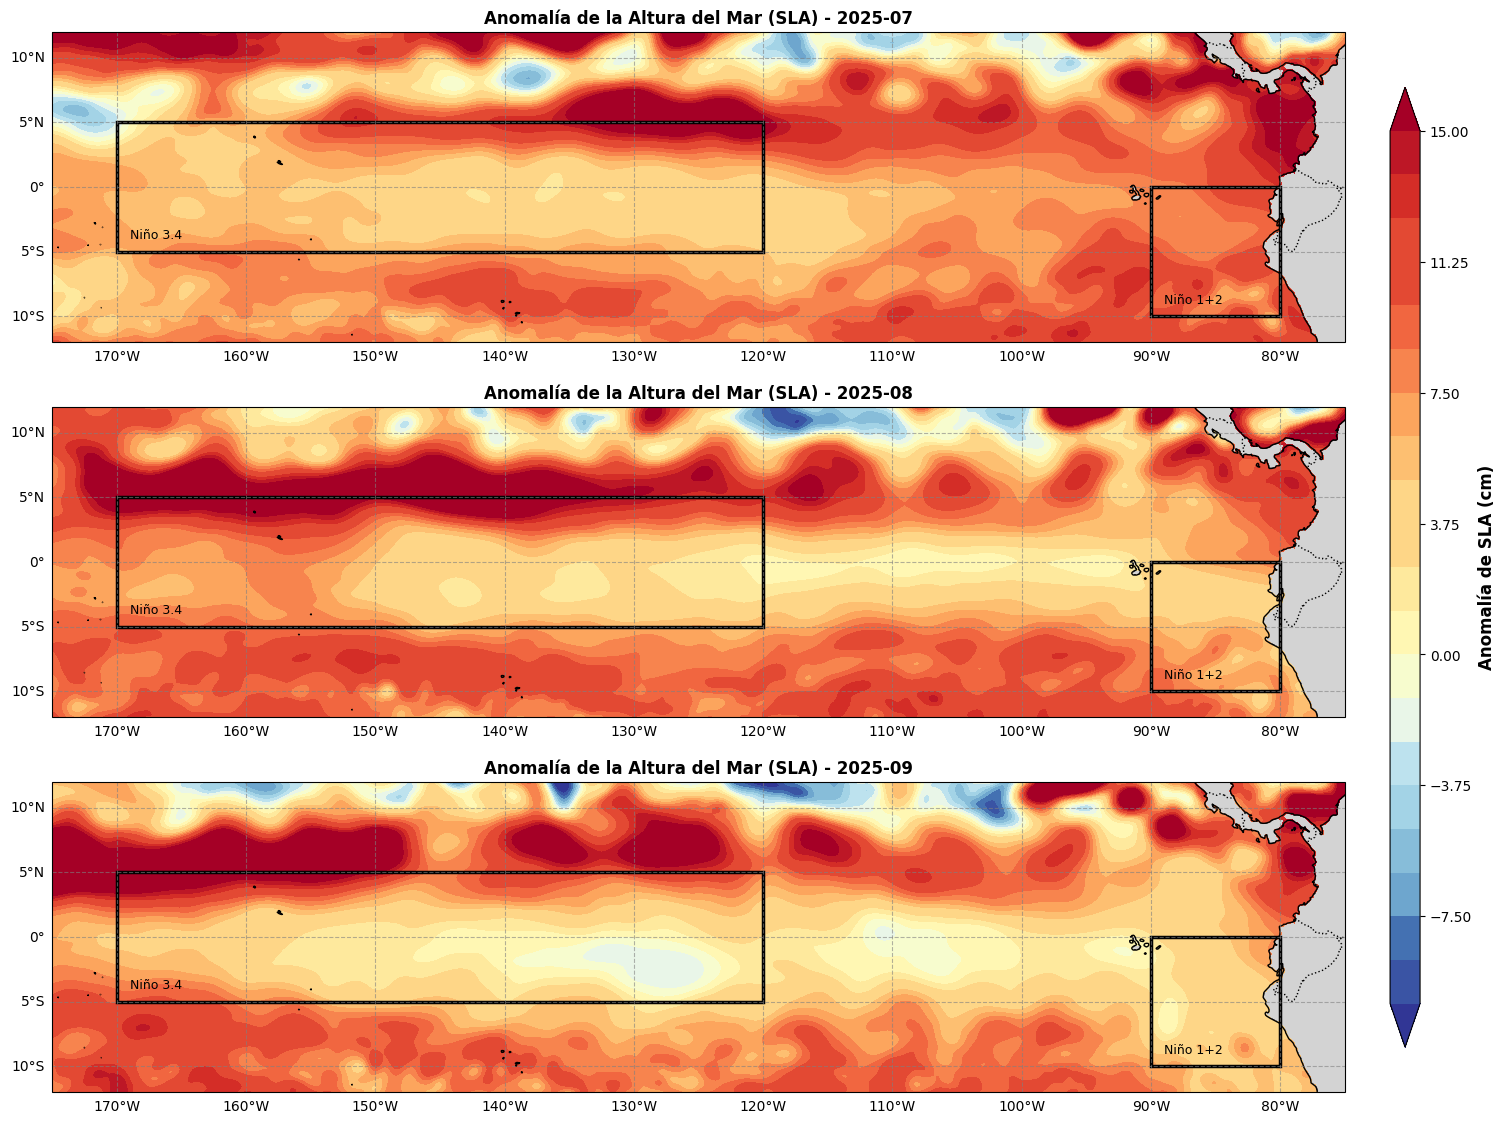

In [19]:
plot_sla_monthly(sla_monthly["sla"], '2025-07-01', num_months_to_plot=3,
                 min_val=-10, max_val=15, levels=21, save_fig=True)

# Diagramas Hovmoller

In [21]:
import matplotlib.dates as mdates # Para formatear las fechas en el eje Y

In [22]:
def plot_hovmoller_sla(sla_daily_data, lat_band_south=-2, lat_band_north=2,
                        min_val=-10, max_val=10, levels=21,
                        save_fig=False):
    """
    Genera un diagrama de Hovmöller de la Anomalía de la Altura del Mar (SLA),
    promediado sobre una banda de latitud específica (por defecto 2°S a 2°N).

    Args:
        sla_daily_data (xr.DataArray): DataArray diario de SLA con dimensiones 'time', 'latitude', 'longitude'.
                                        La variable debe llamarse 'sla'.
        lat_band_south (float): Límite sur de la banda de latitud para el promedio (por defecto -2 grados).
        lat_band_north (float): Límite norte de la banda de latitud para el promedio (por defecto 2 grados).
        min_val (float): Valor mínimo para la escala de colores (por defecto -10 cm).
        max_val (float): Valor máximo para la escala de colores (por defecto 10 cm).
        levels (int): Número de niveles para el contorno de color (por defecto 21).
        save_fig (bool): Si es True, la figura se guardará en un archivo. (Por defecto False).
        output_path (str): Ruta del directorio donde se guardará la figura si save_fig es True.
                           (Por defecto ".", que es el directorio actual).
        output_filename (str): Nombre del archivo para guardar la figura (por defecto "hovmoller_sla.png").
    """

    # Multiplicar por 100 para convertir de metros a centímetros (si tus datos están en metros).
    # Si tus datos ya están en cm, comenta o elimina esta línea.
    sla_data_cm = sla_daily_data * 100.0

    # 1. Seleccionar la región de latitud y promediar
    # .sel() selecciona los datos dentro del rango, .mean() promedia a lo largo de 'latitude'
    # .squeeze() elimina la dimensión 'latitude' que ahora tiene tamaño 1
    sla_hovmoller = sla_data_cm.sel(latitude=slice(lat_band_south, lat_band_north)).mean(dim='latitude').squeeze()

    # Asegúrate de que el DataArray resultante tenga las dimensiones correctas (time, longitude)
    if 'latitude' in sla_hovmoller.dims:
        raise ValueError("Error en el promedio: la dimensión 'latitude' no fue eliminada. "
                         "Verifica que el rango de latitud contenga datos.")

    # Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8)) # Un solo subplot para el Hovmöller

    # Definir los niveles de contorno y la normalización de color
    contour_levels = np.linspace(min_val, max_val, levels)
    norm = mcolors.TwoSlopeNorm(vmin=min_val, vcenter=0., vmax=max_val) # Asume 0 es el centro

    # Graficar el diagrama de Hovmöller
    # Usamos .plot.contourf para la visualización con niveles y cmap
    # x='longitude' y y='time' son las dimensiones de tu sla_hovmoller
    plot_obj = sla_hovmoller.plot.contourf(
        ax=ax,
        x='longitude',
        y='time',
        levels=contour_levels,
        cmap='RdYlBu_r', # Usamos 'coolwarm' como pediste en funciones anteriores
        norm=norm,
        add_colorbar=False, # Añadiremos nuestra propia barra de color
        extend='both' # Extiende los colores si los datos están fuera de min/max_val
    )

    # Configurar etiquetas y título
    ax.set_title(f'Diagrama de Hovmöller de SLA - (Franja {lat_band_south*-1}°S a {lat_band_north}°N)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitud (°)', fontsize=12) # O (°W) si manejas longitudes negativas
    ax.set_ylabel('Fecha', fontsize=12)

    # Formatear el eje Y (tiempo) para que se vea mejor
    locator = mdates.AutoDateLocator()
    formatter = mdates.DateFormatter('%Y-%m-%d') # Formato Año-Mes-Día
    ax.yaxis.set_major_locator(locator)
    ax.yaxis.set_major_formatter(formatter)
    ax.invert_yaxis()
    fig.autofmt_xdate() # Ajusta automáticamente la inclinación de las etiquetas de fecha si se superponen

    # Añadir la barra de color
    cbar = plt.colorbar(plot_obj, ax=ax, orientation='vertical', pad=0.05)
    cbar.set_label('Anomalía de SLA (cm)', fontsize=12, fontweight='bold')
    if save_fig:
        plt.savefig(f"{path_guardar}/Hovmoller_2S_2N.png", dpi=300, bbox_inches='tight') # dpi=300 para buena calidad
        print(f"Figura guardada como: Hovmoller_2S_2N.png")
    else:
      plt.show()

Figura guardada como: Hovmoller_2S_2N.png


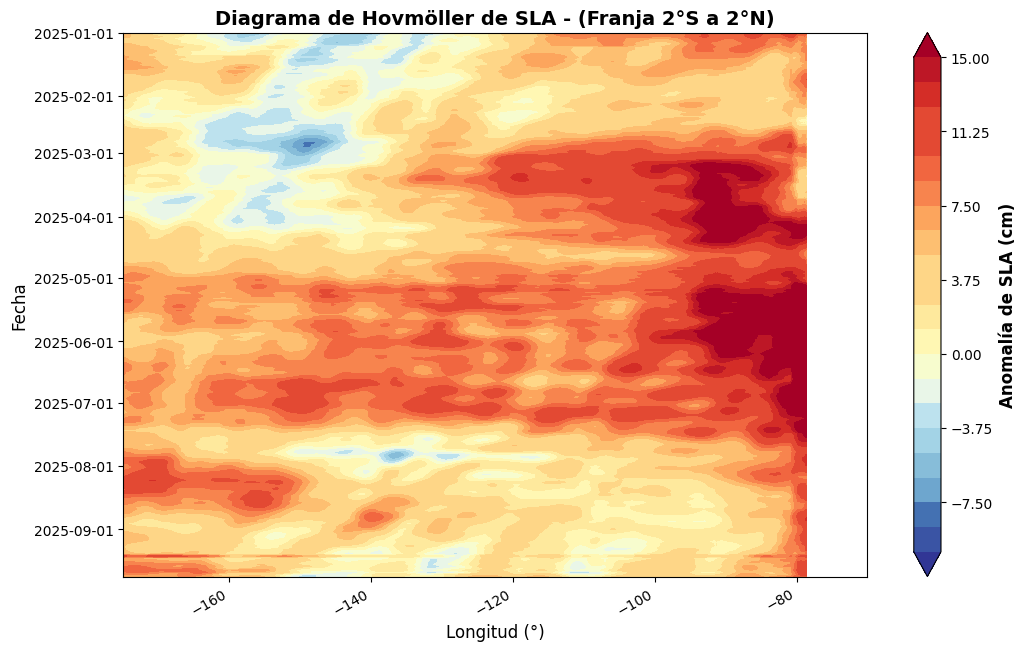

In [23]:
plot_hovmoller_sla(sla_daily_manual["sla"],lat_band_south=-2, lat_band_north=2,
                        min_val=-10, max_val=15, levels=21,
                        save_fig=True)